# Transformers: Revolutionizing Natural Language Processing

Transformers models have emerged as the cutting-edge technology in the field of natural language processing. They have significantly advanced the capabilities of NLP models, achieving state-of-the-art performance on various tasks.

[Hugging Face](https://huggingface.co/) offers one of the most practical and comprehensive [libraries](https://huggingface.co/docs/transformers/main/en/index) for working with transformers and pre-trained models.

**Hugging Face Transformers**: This library provides a user-friendly and powerful toolkit for working with transformers. It offers access to a wide range of pre-trained transformer models, making it easier than ever to leverage the latest advancements in NLP. With Hugging Face Transformers, you can quickly implement transformer-based solutions for tasks such as text classification, machine translation, and question-answering.

In [1]:
!pip install transformers datasets 2>&1
!pip install accelerate -U  2>&1
!pip install transformers[torch]  2>&1
!wget https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv 2>&1
!wget https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/test.csv 2>&1

--2025-12-08 14:42:02--  https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv [following]
--2025-12-08 14:42:02--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29470338 (28M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  28.10M  --.-KB/s    in 0.1s    

2025-12-08 14:42:02 (188 MB/s) - ‘train.csv’ saved [29470338/29470338]

--2025-1

We will use the Hugging Face Transformers library to implement a transformer-based text classifier.  
First, we will load our data and prepare it for use with torch and the transformers library.

In [2]:
import pandas as pd

train_df = pd.read_csv('train.csv', names=["label", "title", "text"]).sample(40000)
test_df = pd.read_csv('test.csv', names=["label", "title", "text"]).sample(2000)
train_text, train_labels = train_df["text"], train_df['label']-1
test_text, test_labels = test_df["text"], test_df['label']-1

We will use the `distilbert-base-uncased` model, which is a distilled version of the popular [BERT](https://arxiv.org/abs/1810.04805) model. Distilled models are smaller and faster than their full-size counterparts, making them ideal for applications with limited computational resources.  
BERT uses a particular tokenization method called [WordPiece](https://huggingface.co/learn/nlp-course/chapter6/6?fw=pt), which is different from the tokenization method we used previously. Therefore, we will need to use the `DistilBertTokenizer` class to tokenize our data.  

In [3]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class NlpDataset(Dataset):
    def __init__(self,data,labels,tokenizer):
        self.data = data.to_list()
        self.labels = labels.tolist()
        self.encodings = tokenizer(self.data, truncation=True, padding=True)

    def __getitem__(self,idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx],dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = NlpDataset(train_text, train_labels, tokenizer)
test_dataset = NlpDataset(test_text,test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Look at a sample yielded by your train loader.  
Its a dictionary with the following keys:
- input_ids: the tokenized text
- attention_mask: a mask to ignore padding
- labels: the labels

Input_ids are the tokenized text and labels are the labels.  
The attention mask is a mask to ignore padding. Indeed, the model will pad the sequences to have the same length. The attention mask will tell the model to ignore the padding.  

In [4]:
next(iter(train_loader))

{'input_ids': tensor([[  101,  2446,  3097,  ...,     0,     0,     0],
         [  101,  6627,  8545,  ...,     0,     0,     0],
         [  101, 12616,  1998,  ...,     0,     0,     0],
         ...,
         [  101,  7513, 13058,  ...,     0,     0,     0],
         [  101,  6178,  4691,  ...,     0,     0,     0],
         [  101,  2048, 13773,  ...,     0,     0,     0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'labels': tensor([0, 3, 2, 2, 2, 2, 1, 2, 0, 2, 2, 3, 2, 0, 1, 0, 1, 3, 1, 2, 1, 2, 2, 3,
         2, 2, 2, 2, 1, 0, 0, 1, 1, 1, 3, 3, 1, 3, 1, 0, 2, 3, 0, 0, 1, 1, 2, 0,
         3, 2, 0, 2, 3, 2, 2, 3, 1, 0, 1, 0, 3, 3, 1, 2])}

We will now instanciate our model and wrapp it into a Pytorch module.
In this practical session we will freeze the model and only train the last layer.  
This is not the best practice when using BERT but we will do it for the sake of simplicity.  
Take a particular attention to the `forward` method.  
The model will return a tuple with the logits, the hidden states and the attentions.  
The logits are the outputs of the last layer.
The hidden states are the outputs of all the layers and will contain the embeddings of the text.
The attentions are the attention weights of the model.

In [5]:
from transformers import  DistilBertForSequenceClassification
import torch.nn as nn

class BertClf(nn.Module):

    def __init__(self, distilbert):

        super(BertClf, self).__init__()

        self.distilbert = distilbert
        for name, param in distilbert.named_parameters():
            if not "classifier" in name:
                param.requires_grad = False

    def forward(self, sent_id, mask):

        out = self.distilbert(sent_id, attention_mask=mask)
        logits = out.logits
        attn = out.attentions
        hidden_states = out.hidden_states


        return logits,hidden_states,attn

distilbert = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",
                                                                  num_labels=4,
                                                                  output_attentions=True,
                                                                  output_hidden_states=True)

model = BertClf(distilbert)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Now complete the following training and testing functions.

In [6]:
from tqdm.notebook import tqdm

def train_bert(model, optimizer, dataloader, epochs):
  model.train()
  for epoch in range(epochs):
    running_loss = 0.0
    running_corrects = 0
    total = 0
    t = tqdm(dataloader)
    for i, batch in enumerate(t):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        preds, _, _ = model(input_ids, attention_mask)
        loss = criterion(preds,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = preds.max(1)
        running_corrects += predicted.eq(labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

        t.set_description(f"epoch:{epoch} loss: {(running_loss / (i+1)):.4f} current accuracy:{round(running_corrects / total * 100, 2)}%")

def test_bert(model, dataloader):
    model.eval()
    test_corrects = 0
    total = 0
    with torch.no_grad():
      for batch in tqdm(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        preds, _, _ = model(input_ids,attention_mask)
        _, predicted = preds.max(1)
        test_corrects += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return test_corrects / total

We will now compare the performance of our transformer-based model with the previous models.  

In [7]:
from torch.optim import AdamW

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = AdamW(model.parameters(),lr = 1e-5)
criterion  = nn.CrossEntropyLoss()
n_epochs = 1

train_bert(model, optimizer, train_loader, n_epochs)
test_bert(model, test_loader)

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

0.849

The following function get the embeddings of each text.
BERT use a speacial token `[CLS]` to represent the whole text.  
We will use the hidden states of this token as the embeddings of the text.

In [8]:
import numpy as np
test_loader = DataLoader(test_dataset, batch_size=1)


def get_embeddings(model, dataloader):
    model.eval()
    embeddings = []
    labels = []
    with torch.no_grad():
      for batch in tqdm(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels.append(batch["labels"].item())

        _, emb, _ = model(input_ids,mask=attention_mask)
        last_layer_cls = emb[-1][:,0,:]
        embeddings.append(last_layer_cls.squeeze(0).squeeze(0))
    embeddings = np.array([e.cpu().numpy() for e in embeddings])
    return embeddings, labels

embeddings, labels = get_embeddings(model, test_loader)

  0%|          | 0/2000 [00:00<?, ?it/s]

Now plot the embeddings of each text on a t-SNE.  
What do you think of these representations?

<Axes: >

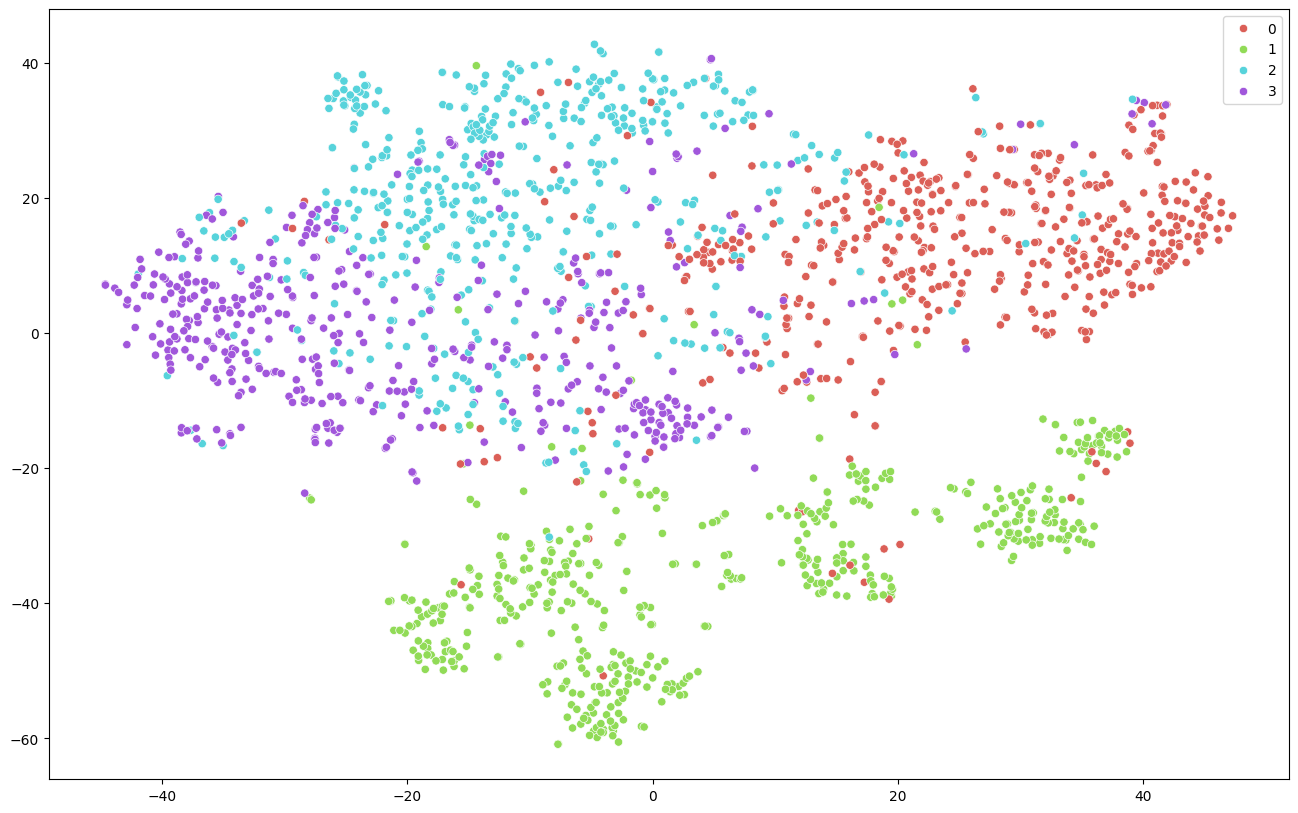

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, init='random')
X_tsne = tsne.fit_transform(embeddings)
plt.figure(figsize=(16,10))
sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1],
    hue=labels,
    palette=sns.color_palette("hls", 4),
    legend="full")

We can use[ **bertviz** library](https://github.com/jessevig/bertviz) to visualize the attention weights of the model.
Remember that the attention weights represent the relation between the tokens.
Attention weights are very useful to understand how the model works and what it focuses on.

In [11]:
!pip install bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.7 MB/s eta 0:00:00


Here is a text example:

In [12]:
from bertviz import model_view, head_view

sentence = test_df["text"].iloc[33]
tokenized = tokenizer(sentence)
print(sentence)
print(tokenized)

Microsoft said today that it plans to give customers three days' advance notice about its monthly security updates to help them prepare to install related software patches.
{'input_ids': [101, 7513, 2056, 2651, 2008, 2009, 3488, 2000, 2507, 6304, 2093, 2420, 1005, 5083, 5060, 2055, 2049, 7058, 3036, 14409, 2000, 2393, 2068, 7374, 2000, 16500, 3141, 4007, 13864, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


We will use the `model_view` function to visualize the attention weights of the model.  
Here, each row represents a layer of the model and each column represents a head of the model.
The darker the color, the higher the attention weight.  
You may observe that some attention heads catche different relations between words.


In [13]:
inputs = torch.tensor(tokenized["input_ids"]).unsqueeze(0).to(device)
mask = torch.tensor(tokenized["attention_mask"]).unsqueeze(0).to(device)
outputs = model(inputs,mask = mask)
attention = outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs[0])
model_view(attention, tokens)

<IPython.core.display.Javascript object>

The ```head_view``` function allows to visualize the attention weights of a particular head of the model.

In [14]:
head_view(attention, tokens)

<IPython.core.display.Javascript object>

That's it for this practical session.
By now, you should have a good understanding of how to encode text data and use it to train a machine learning model.  
You should also be familiar with the latest advancements in NLP, including transformers and pre-trained models.   
We hope you enjoyed this practical session and that you will be able to apply what you've learned to your own projects.